**Data analysis topic background**

Recent news reports have observed and highlighted the trend of COE premium prices rising sharply over the recent few years. Doing a quick internet search lists the following potential reasons for the increase:

[1] Impact of electric vehicles 

The growing popularity of Chinese EVs offers higher build quality and competitive pricing, tempting buyers to switch. Government incentives, such as the EV Early Adoption Incentive (EEAI) and Vehicular Emissions Scheme (VES), allow buyers to "save" on the car cost, allowing them to pay higher premiums for COEs. New buyers are aware that electric charging prices when switching to EVs are much cheaper than petrol usage prices for traditional internal combustion engine cars.

[2] Sustained and strong demand

a) Due to increasing affluence as rising household incomes have increased the number of people who can afford a car, making the bids to limited pool of available COE licenses competitive

b) Private hire vehicle fleets. Ride hailing and car sharing companies are large scale bidders looking to expand their fleets.

**Objective of notebook**

[a] Using relevant data.gov.sg HDB datasets, investigate, evaluate and conclude if the claims in potential reasons 1 & 2 listed above in background are correct from study period 2020 to 2024. This is broken down to objectives shown in next point B.

[b] Therefore, this notebook will perform exploratory data analysis (EDA) to evaluate these objectives:
1) Investigate and verify the trend of COE prices for category A, B & E in study period 2020 to 2024.
2) Investigate the annual car population and new car registration to verify the trends in vehicle make types. Investigate trends of vehicle ownership types for motor vehicle population.
3) Investigate if the claim of increasing affluence is correct and the interest rate trend for unsecured loans to confirm level of financing costs.
4) Analyze and evaluate the impact of rising COE premiums on average ridership levels for public transportation as side effect of the rising COE premium situation.

[c] Optional section to demostrate the use of SQL database python API to backup processed dataframe data to the mySQL server installed on host computer. The backup data would be queried back and replotted for illustration.

**Prequisite python libraries required to install for running notebook**

To run all cells in this notebook, please ensure your host computer has been installed with the following python libraries or toolkits:

[1] Pandas: conda install -c conda-forge pandas

[2] Numpy: conda install -c conda-forge numpy

[3] Seaborn: conda install -c conda-forge seaborn

[4] Matplotlib: conda install -c conda-forge matplotlib

[5] Bokeh: conda install -c conda-forge bokeh

For running the optional database section:

[6] mySQL connector: conda install -c conda-forge mysql-connector-python

**Also, please ensure mySQL server is installed and database connection for local host IP is valid and tested working**

**Instructions to user**

[1] Ensure the python libraries and toolkits mentioned in previous section "Prequisite python libraries required to install for running notebook" have been installed on your host computer.

[2] If you would like to run optional database section:

a) **please ensure mySQL server is installed and database connection for local host IP is valid and tested working**

b) Set the global variable "doYouWantToRunAllSQL" defined in setup section cell to "True". Else set it to "False" to skip whole section.

c) Specify the user name, password, host IP for mySQL server connection in the setup section cell

[3] Next, click "Run > Run all cells" menu option to run all cells from first cell to last cell.

[4] Generated output results analysis plots by seaborn (non-interactive) would be saved in jpg format in project directory under "figure" folder for reference and subsequent usage. 

[5] Some generated plots are made interactive to user.

---------------------------
**Setup section**

Perform variable declarations and other necessary operations to implement setup procedures before the running the python routines in the main sections that build upon it.

In [ ]:
# Please define if you want to run SQL operations in optional Database section after main notebook sections are done
# Set True if you are ready to run python mySQL connector API functions on available mySQL server installed on host computer. Else set to false to skip entire Database section.
# This flag applies only to optional database section and does NOT affect the main notebook EDA notebook sections
doYouWantToRunAllSQL = False 
# Pre-defined user, pw, host IP for mySQL installed on host computer. Prefined name for database to create on host computer by SQL section.
user, pw, host, db = 'root', 'nsfswbdd123', '127.0.0.1', 'it8701ca2'

**DO NOT MODIFY THE GLOBAL DEFINED DICTIONARY dataset_files and figure_files, it has been pre-defined based on the project files**

In [2]:
# pre-defined for whole notebook, dictionary of consolidated variables mapping to actual file path for raw dataset files
dataset_files = { 
                  "dataset_1_1": "data/1/COEBiddingResultsPrices.csv", 
                  "dataset_2_1": "data/2/AnnualCarPopulationbyMake.csv",
                  "dataset_2_2": "data/2/NewRegistrationofCarsbyMake.csv",
                  "dataset_2_3": "data/2/MotorVehiclePopulationByTypeOfVehicleEndOfPeriodAnnual.csv",
                  "dataset_3_1": "data/3/CurrentBanksInterestRatesEndOfPeriodMonthly.csv",
                  "dataset_3_2": "data/3/TaxableIndividualsbyAssessedIncomeGroup.csv",
                  "dataset_4_1": "data/4/PublicTransportOperationAndRidershipAnnual.csv"
                }
# pre-defined figure file paths for saving matplotlib plots to figure subfolder of current notebook path directory for backup 
figure_files =  { 
                  "fig_1_1": "figure/fig_1_1.jpg",
                  "fig_1_2": "figure/fig_1_2.jpg",            
                  "fig_2_3": "figure/fig_2_3.jpg",
                  "fig_4_1": "figure/fig_4_1.jpg"
                }

---------------------------
**Section 1**

**section 1.1) data_set_1_1**

data.gov.sg dataset: COE Bidding Results / Prices

URL: https://data.gov.sg/datasets/d_69b3380ad7e51aff3a7dcc84eba52b8a/view

filename: COEBiddingResultsPrices.csv

output result analysis plot filename: fig_1_1.jpg, fig_1_2.jpg

output plot type: Box plot and heat map

**Section 1.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2020-2024 and filter for Category A, B and E.

[3] Array mathematics
- Perform median calcuation of respective COE premiums for whole year for each category type

[4] Transformation to new dataset
- Generate new rows of filtered statistics with year and COE category type and save to new pandas dataframe
- Generate new rows of median statistics with year and COE category type and save to another new pandas dataframe

[5] Data presentation 
- Perform various plot adjustments and annotations to plot statistics to answer section objective

In [3]:
import pandas as pd
import copy

def check_and_fill_na(df_in, fill_value=0):
    total_nans_df = int(df_in.isna().sum().sum())
    print(f"Check total NaNs in DataFrame: {total_nans_df}")
    if total_nans_df > 0:
        df_in = df_in.fillna(fill_value)
    else:
        print(f"No need to fill na to {fill_value} in DataFrame")

def extract_year_medians(df_source, years, vehicle_class):
    catA_median_premium_ls = []
    for year in years:
        df_filter = df_source[(df_source['year'] == year) & (df_source['vehicle_class'] == vehicle_class)]
        catA_premium_median = int(df_filter['premium'].median())
        catA_median_premium_ls.append(catA_premium_median)
        df_filter = None
    return catA_median_premium_ls

debug_on = False
filename = dataset_files["dataset_1_1"]
df_0 = pd.read_csv(filename, sep=',')
#print(df_0.head(5))
#print(df_0.count())

years = ('2020', '2021', '2022', '2023', '2024')
vehicle_classes = ('Category A', 'Category B', 'Category E')
# perform boolean masking for filtering according to years and vehicle_classes
df_1 = df_0[df_0['month'].str.startswith(years) & df_0['vehicle_class'].str.startswith(vehicle_classes)]
check_and_fill_na(df_1)

for index_id in df_1.index:
    cell_value = copy.deepcopy(df_1.loc[index_id,'month'])
    df_1.loc[index_id,'month'] = cell_value.split('-')[0]
    #print(f"Before: {cell_value}, After: {df_1.loc[index_id,'month']}")

df_1 = df_1.rename(columns={'month': 'year'})
# print(df_1.head(5))
# print(df_1.tail(5))

years_reversed = (list(years))[::-1]
catA_median_premium_ls = extract_year_medians(df_1, years_reversed, 'Category A')
catB_median_premium_ls = extract_year_medians(df_1, years_reversed, 'Category B')
catE_median_premium_ls = extract_year_medians(df_1, years_reversed, 'Category E')

dataset_fig_1a = df_1
dataset_fig_1b = {'years': years_reversed, 'data': catA_median_premium_ls, 'dataset': "Yearly CAT A premium median"}

newdf_col_dict = {'Category_A': catA_median_premium_ls[::-1], 'Category_B': catB_median_premium_ls[::-1], 'Category_E': catE_median_premium_ls[::-1]}
newdf_index = (list(years))
df_2 = pd.DataFrame(newdf_col_dict, index=newdf_index)
dataset_fig_1c = df_2

print(dataset_fig_1a)
print(dataset_fig_1b)
print(dataset_fig_1c)

df_0 = df_1 = df_2 = None

Check total NaNs in DataFrame: 0
No need to fill na to 0 in DataFrame
      year  bidding_no vehicle_class  quota bids_success bids_received  \
1200  2020           1    Category A   1035         1026          1450   
1201  2020           1    Category B   1022         1021          1229   
1204  2020           1    Category E    384          377           541   
1205  2020           2    Category A   1034         1025          1390   
1206  2020           2    Category B   1012         1008          1157   
...    ...         ...           ...    ...          ...           ...   
1761  2024           1    Category B    689          689           866   
1764  2024           1    Category E    179          167           326   
1765  2024           2    Category A   1035          998         1,506   
1766  2024           2    Category B    676          667           987   
1769  2024           2    Category E    182          170           330   

      premium  
1200    35320  
1201    3

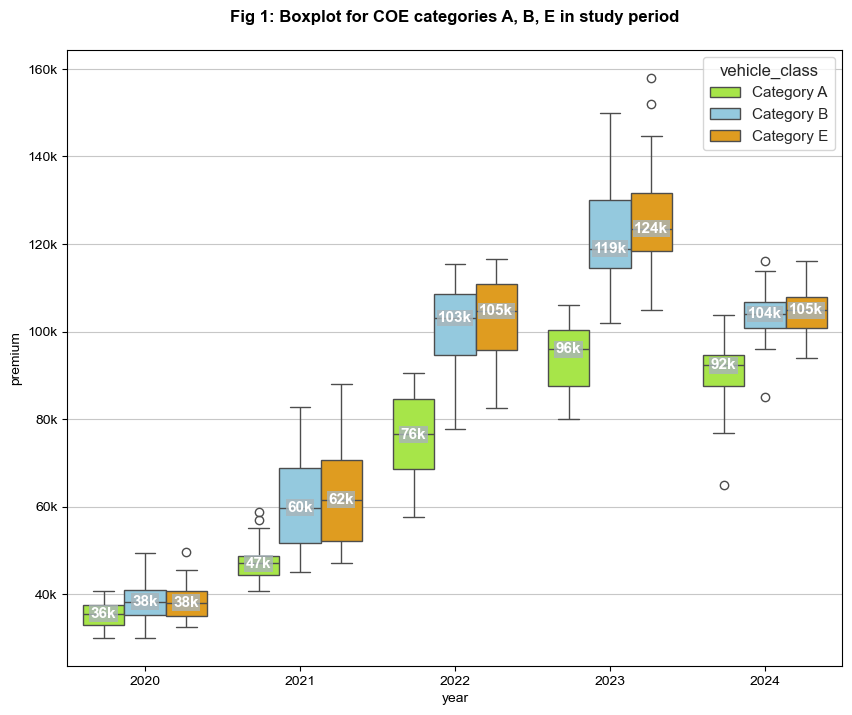

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def annotate_plot_medians(ax):
    for i, line in enumerate(ax.get_lines()):
        if i % 6 == 4: 
            x_coords = line.get_xdata()
            y_coords = line.get_ydata()
            
            x_center = x_coords.mean()
            y_val = y_coords[0] 
            
            ax.text(x_center, y_val, f'{y_val/1000:.0f}k', 
                    ha='center', va='center', fontweight='bold', 
                    size=11, color='white',
                    bbox=dict(facecolor="#A9B4B9D9", alpha=0.8, edgecolor='none', pad=1))

def plot_formatting(ax):
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1000:g}k'))
    ax.grid(True, axis='y', linestyle='-', alpha=0.7)

fig, ax = plt.subplots(figsize=(10, 8)) 

sns.set_theme(style="ticks", palette="pastel")
sns.boxplot(x="year", y="premium", hue="vehicle_class", palette=["greenyellow", "skyblue", "orange"], data=dataset_fig_1a, ax=ax)
annotate_plot_medians(ax)
plot_formatting(ax)
ax.set_title("Fig 1: Boxplot for COE categories A, B, E in study period", fontsize=12, fontweight='bold', pad=20)

plt.savefig(figure_files["fig_1_1"], dpi=300, bbox_inches='tight')
plt.show()

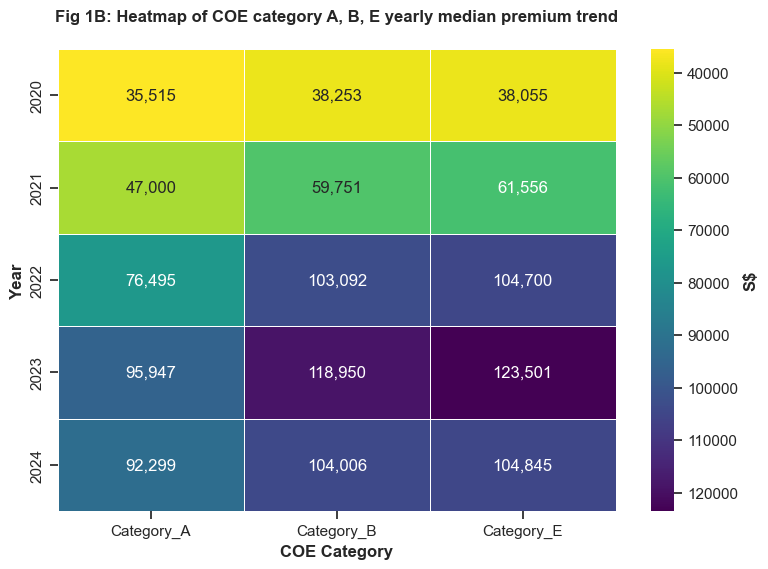

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(9, 6))
hm_sns = sns.heatmap(dataset_fig_1c, annot=True, fmt=",d", linewidths=.5, cmap="viridis_r", ax=ax)

cbar = hm_sns.collections[0].colorbar
cbar.ax.invert_yaxis()
cbar.set_label("S$", fontdict={'fontweight': 'bold', 'fontsize': 12})

ax.set_xlabel("COE Category", fontdict={'fontweight': 'bold', 'fontsize': 12})
ax.set_ylabel("Year", fontdict={'fontweight': 'bold', 'fontsize': 12})
ax.set_title("Fig 1B: Heatmap of COE category A, B, E yearly median premium trend", pad=20, fontdict={'fontweight': 'bold', 'fontsize': 12})

plt.savefig(figure_files["fig_1_2"], dpi=300, bbox_inches='tight')
plt.show()

---------------------------
**Section 2**

**section 2.1) data_set_2_1**

data.gov.sg dataset: Annual Car Population by Make

URL: https://data.gov.sg/datasets/d_20d3fc7f08caa581c5586df51a8993c5/view

filename: AnnualCarPopulationbyMake.csv 

output result analysis plot filename: N.A. (interactive bokeh plot in notebook)

output plot type: Interactive bar chart

**section 2.2) data_set_2_2**

data.gov.sg dataset: New Registration of Cars by Make

URL: https://data.gov.sg/datasets/d_d3f4d708e1d0a37b4365414e2fad3a07/view

filename: NewRegistrationofCarsbyMake.csv

output result analysis plot filename: N.A. (interactive bokeh plot in notebook)

output plot type: Interactive bar chart

**section 2.3) data_set_2_3**

data.gov.sg dataset: Motor Vehicle Population By Type Of Vehicle (End Of Period), Annual

URL: https://data.gov.sg/datasets/d_aa457c0abaacccefd238c31cfed211d9/view

filename: MotorVehiclePopulationByTypeOfVehicleEndOfPeriodAnnual.csv

output result analysis plot filename: fig_2_3.jpg

output plot type: Pie chart

**Section 2.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2020-2024 

[3] Array mathematics
- Perform group-by of filtered dataframe and then summation for whole year for each fuel type

[4] Transformation to new dataset
- Perform pivot operation to enable fuel type to be used as columns with values as number
- Convert pivot table to pandas dataframe for subsequent plotting

[5] Data presentation 
- Perform various plot adjustments and enable interactive features to plot statistics to answer section objective

In [6]:
import pandas as pd

def df_inspection(df_check):
    print("----- Inspecting original dataframe ----- ")
    print("--- column datatypes ---")
    print(df_check.dtypes)
    print("--- column counts ---")
    print(df_check.count())
    print("--- Sampling head rows --- ")
    print(df_check.head(5))
    print("----- End of inspecting ----- ")

debug_on = False

filename = dataset_files["dataset_2_1"]
df_0 = pd.read_csv(filename, sep=',')
df_inspection(df_0)

df_0['number'] = df_0['number'].fillna(0)
df_0 = df_0.astype({'year': 'str', 'number': 'int64'})

years = ('2022', '2023', '2024')

df_1 = df_0[df_0['year'].str.startswith(years)]

print(df_1.head(5))
print(df_1.tail(5))
print(df_1.dtypes)

# perform group-by with summation here to focus on year and fuel type
# grpby_1 = df_1.groupby(['year', 'fuel_type'])['number'].sum()
# grpby_1 = df_1.groupby(['year', 'fuel_type'])
grpby_2 = df_1.groupby(['year', 'fuel_type'])['number'].sum()

print(grpby_2)

# perform pivot operation here so that fuel type made as columns with values as number
df_2 = grpby_2.reset_index()
pivoted = df_2.pivot(index='year', columns='fuel_type', values='number')
print(pivoted)

for index_id in pivoted.index:
    pivoted.loc[index_id,'Diesel-Electric'] = pivoted.loc[index_id,'Diesel-Electric'] + pivoted.loc[index_id,'Diesel-Electric (Plug-In)']
    pivoted.loc[index_id,'Petrol-Electric'] = pivoted.loc[index_id,'Petrol-Electric'] + pivoted.loc[index_id,'Petrol-Electric (Plug-In)']

dataset_fig_2_1 = pivoted.drop(columns=['Diesel-Electric (Plug-In)', 'Petrol-Electric (Plug-In)'])
df_0 = df_1 = df_2 = pivoted = None

print(dataset_fig_2_1)

----- Inspecting original dataframe ----- 
--- column datatypes ---
year           int64
make          object
fuel_type     object
number       float64
dtype: object
--- column counts ---
year         1943
make         1943
fuel_type     682
number       1894
dtype: int64
--- Sampling head rows --- 
   year          make fuel_type   number
0  2005    ALFA ROMEO       NaN    914.0
1  2005  ASTON MARTIN       NaN     23.0
2  2005          AUDI       NaN   2025.0
3  2005        AUSTIN       NaN    137.0
4  2005        B.M.W.       NaN  15351.0
----- End of inspecting ----- 
      year        make fuel_type  number
1261  2022  ALFA ROMEO    Petrol     457
1262  2022      ALPINA    Petrol      51
1263  2022      ALPINA    Diesel      20
1264  2022      ALPINE    Petrol      42
1265  2022       ALVIS    Petrol       2
      year      make fuel_type  number
1938  2024  WOLSELEY    Petrol       2
1939  2024    WULING    Petrol       0
1940  2024     XPENG  Electric     336
1941  2024     ZEEKR

In [ ]:
from bokeh.models import ColumnDataSource, FactorRange, NumeralTickFormatter
from bokeh.palettes import MediumContrast6
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap
from bokeh.io import output_notebook
output_notebook()

print(dataset_fig_2_1)

dataset_fig_2_1_dict = dataset_fig_2_1.to_dict(orient='list')

years = list(dataset_fig_2_1.index)
types = list(dataset_fig_2_1_dict.keys())

data = {'years' : years}
data = {**data, **dataset_fig_2_1_dict}

# print(years)
# print(data)

x = [ (year, type) for year in years for type in types ]
counts = sum(zip (data['Diesel'], data['Diesel-Electric'], data['Electric'], data['Petrol'], data['Petrol-CNG'], data['Petrol-Electric']) , ()) 

source = ColumnDataSource(data=dict(x=x, counts=counts))

tooltips = [("Year, Type", "@x"), ("Count", "@counts{0,0}")]

p = figure(x_range=FactorRange(*x), height=600, width=800, title="Fig 2.1: Annual car population by fuel type",
           toolbar_location=None, tools="hover", tooltips=tooltips ,output_backend="svg")
p.vbar(x='x', top='counts', width=0.9, source=source, line_color="white",
       fill_color=factor_cmap('x', palette=MediumContrast6, factors=types, start=1, end=2))

p.y_range.start = 0
p.x_range.range_padding = 0.1
p.xaxis.major_label_orientation = 1
p.xgrid.grid_line_color = None
p.yaxis.formatter = NumeralTickFormatter(format="0,0")
p.yaxis.axis_label = "Vehicle units"

p.title.text_font_size = "16pt"
p.title.align = "center"
p.title.text_font_style = "bold"

show(p)
# note if bokeh plot does not show after running all cells, run this individual cell again and the bokeh plot should appear

Loading BokehJS ...

fuel_type  Diesel  Diesel-Electric  Electric  Petrol  Petrol-CNG  \
year                                                               
2022        18638               20      6569  560504         143   
2023        18394               19     12018  542511          85   
2024        17125               14     26339  515787          74   

fuel_type  Petrol-Electric  
year                        
2022                 67090  
2023                 80741  
2024                101000  


**Section 2.2**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2020-2024 

[3] Array mathematics
- Perform group-by of filtered dataframe and then summation for whole year for each fuel type

[4] Transformation to new dataset
- Perform pivot operation to enable fuel type to be used as columns with values as number
- Convert pivot table to pandas dataframe for subsequent plotting

[5] Data presentation 
- Perform various plot adjustments and enable interactive features to plot statistics to answer section objective

In [8]:
import pandas as pd

def df_inspection(df_check):
    print("----- Inspecting original dataframe ----- ")
    print("--- column datatypes ---")
    print(df_check.dtypes)
    print("--- column counts ---")
    print(df_check.count())
    print("--- Sampling head rows --- ")
    print(df_check.head(5))
    print("----- End of inspecting ----- ")

def convert_col_month_to_year(df_in):
    for index_id in df_in.index:
        cell_value = df_in.loc[index_id,'month']
        df_in.loc[index_id,'month'] = cell_value.split('-')[0]

debug_on = False

filename = dataset_files["dataset_2_2"]
df_0 = pd.read_csv(filename, sep=',')
df_inspection(df_0)

df_0 = df_0.drop(columns=['make', 'importer_type', 'vehicle_type'])
df_0['number'] = df_0['number'].fillna(0)
df_0 = df_0.astype({'number': 'int64'})

print(df_0.head(5))

years = ('2020', '2021', '2022', '2023', '2024')
df_1 = df_0[df_0['month'].str.startswith(years)]

convert_col_month_to_year(df_1)

df_1 = df_1.rename(columns={'month': 'year'})

print(df_1.head(5))
print(df_1.tail(5))
print(df_1.dtypes)

grpby1 = df_1.groupby(['year', 'fuel_type'])['number'].sum()
print(grpby1)

df_2 = grpby1.reset_index()
print(df_2)

pivoted = df_2.pivot(index='year', columns='fuel_type', values='number')
pivoted.fillna(0, inplace=True)
pivoted = pivoted.astype('int64') 

print(pivoted)

for index_id in pivoted.index:
    pivoted.loc[index_id,'Electric'] = pivoted.loc[index_id,'Electric'] + pivoted.loc[index_id,'Diesel-Electric'] + pivoted.loc[index_id,'Diesel-Electric (Plug-In)']
    pivoted.loc[index_id,'Petrol-Electric'] = pivoted.loc[index_id,'Petrol-Electric'] + pivoted.loc[index_id,'Petrol-Electric (Plug-In)']

dataset_fig_2_2 = pivoted.drop(columns=['Diesel-Electric', 'Diesel-Electric (Plug-In)', 'Petrol-Electric (Plug-In)'])

print(dataset_fig_2_2)

#df_0 = df_1 = df_2 = pivoted = grpby1 = None

----- Inspecting original dataframe ----- 
--- column datatypes ---
month             object
make              object
importer_type     object
fuel_type         object
vehicle_type      object
number           float64
dtype: object
--- column counts ---
month            51669
make             51669
importer_type    20514
fuel_type        51669
vehicle_type     51669
number           22206
dtype: int64
--- Sampling head rows --- 
     month          make importer_type fuel_type vehicle_type  number
0  2016-01    ALFA ROMEO           NaN    Petrol    Hatchback     3.0
1  2016-01        ALPINA           NaN    Petrol    Hatchback     0.0
2  2016-01  ASTON MARTIN           NaN    Petrol    Hatchback     0.0
3  2016-01          AUDI           NaN    Petrol    Hatchback    45.0
4  2016-01        B.M.W.           NaN    Petrol    Hatchback     5.0
----- End of inspecting ----- 
     month fuel_type  number
0  2016-01    Petrol       3
1  2016-01    Petrol       0
2  2016-01    Petrol       0


In [ ]:
from bokeh.models import ColumnDataSource, FactorRange, NumeralTickFormatter
from bokeh.palettes import MediumContrast5
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap
from bokeh.io import output_notebook
output_notebook()

print(dataset_fig_2_2)

dataset_fig_2_2_dict = dataset_fig_2_2.to_dict(orient='list')

years = list(dataset_fig_2_2.index)
types = list(dataset_fig_2_2_dict.keys())

data = {'years' : years}
data = {**data, **dataset_fig_2_2_dict}

print(years)
print(data)

x = [ (year, type) for year in years for type in types ]
counts = sum(zip (data['Diesel'], data['Electric'], data['Others'], data['Petrol'], data['Petrol-Electric']) , ()) 

source = ColumnDataSource(data=dict(x=x, counts=counts))

tooltips = [("Year, Type", "@x"), ("Count", "@counts{0,0}")]

p = figure(x_range=FactorRange(*x), height=600, width=800, title="Fig 2.2: Annual new car registrations by fuel type",
           toolbar_location=None, tools="hover", tooltips=tooltips ,output_backend="svg")
p.vbar(x='x', top='counts', width=0.9, source=source, line_color="white",
       fill_color=factor_cmap('x', palette=MediumContrast5, factors=types, start=1, end=2))

p.y_range.start = 0
p.x_range.range_padding = 0.1
p.xaxis.major_label_orientation = 1
p.xgrid.grid_line_color = None
p.yaxis.formatter = NumeralTickFormatter(format="0,0")
p.yaxis.axis_label = "Vehicle units"

p.title.text_font_size = "16pt"
p.title.align = "center"
p.title.text_font_style = "bold"

show(p)
# note if bokeh plot does not show after running all cells, run this individual cell again and the bokeh plot should appear

Loading BokehJS ...

fuel_type  Diesel  Electric  Others  Petrol  Petrol-Electric
year                                                        
2020          647         0    7365   36453                0
2021          541         0   15294   29607                0
2022          435      2147    7925   14817             5615
2023          165      5469       0   10461            14130
2024           42     14449       0    7664            20867
['2020', '2021', '2022', '2023', '2024']
{'years': ['2020', '2021', '2022', '2023', '2024'], 'Diesel': [647, 541, 435, 165, 42], 'Electric': [0, 0, 2147, 5469, 14449], 'Others': [7365, 15294, 7925, 0, 0], 'Petrol': [36453, 29607, 14817, 10461, 7664], 'Petrol-Electric': [0, 0, 5615, 14130, 20867]}


**Section 2.3**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2020-2024 

[3] Array mathematics
- Perform calculation of proportion in % of row total for each category

[4] Transformation to new dataset
- Generate new rows of filtered calculated statistics with year and category type and save to new pandas dataframe

[5] Data presentation 
- Perform various plot adjustments and annotations to plot statistics to answer section objective

In [10]:
import pandas as pd

def df_inspection(df_check):
    print("----- Inspecting original dataframe ----- ")
    print("--- column datatypes ---")
    print(df_check.dtypes)
    print("--- column counts ---")
    print(df_check.count())
    print("--- Sampling head rows --- ")
    print(df_check.head(5))
    print("----- End of inspecting ----- ")

debug_on = False

filename = dataset_files["dataset_2_3"]
df_0 = pd.read_csv(filename, sep=',')
df_inspection(df_0)

cols_filter = [str(x) for x in range(2024, 2019, -1)]
cols_filter.insert(0, 'DataSeries')
cols_years = cols_filter[1:]
# perform boolean masking for study period
df_0 = df_0[cols_filter]
# deep copy processed dataframe in quantity data to another dataframe, df1 is store as % data format
df_1 = df_0.copy(deep=True)
col_types_dict = dict.fromkeys(cols_years, 'float64')
df_1 = df_1.astype(col_types_dict)

# extract total statistics row as panda series
series_row_total = df_0.iloc[0]

if debug_on:
    print(df_0)
    print(df_1)
    print(series_row_total)
# perform calculation for proportion of total for each category for each year
for column_name in cols_years:
    df_1[column_name] = ( (df_1[column_name] / series_row_total[column_name]) * 100 ).round(1)

dataset_fig_2_3 = df_1.drop(0)
df_0 = df_1 = series_row_total = None

print(dataset_fig_2_3)

----- Inspecting original dataframe ----- 
--- column datatypes ---
DataSeries    object
2024           int64
2023           int64
2022           int64
2021           int64
               ...  
1965          object
1964          object
1963          object
1962          object
1961          object
Length: 65, dtype: object
--- column counts ---
DataSeries    7
2024          7
2023          7
2022          7
2021          7
             ..
1965          7
1964          7
1963          7
1962          7
1961          7
Length: 65, dtype: int64
--- Sampling head rows --- 
                   DataSeries     2024    2023    2022    2021    2020  \
0                       Total  1007094  996732  995746  988755  973990   
1      Private & Company Cars   569956  572014  580332  579369  565033   
2           Private Hire Cars    90383   81754   72632   67990   71147   
3                       Taxis    13117   13620   14084   14887   15678   
4                       Buses    18698   18249   18239

                   DataSeries  2024  2023  2022  2021  2020
1      Private & Company Cars  56.6  57.4  58.3  58.6  58.0
2           Private Hire Cars   9.0   8.2   7.3   6.9   7.3
3                       Taxis   1.3   1.4   1.4   1.5   1.6
4                       Buses   1.9   1.8   1.8   1.9   2.0
5      Motorcycles & Scooters  14.7  14.4  14.4  14.4  14.5
6      Goods & Other Vehicles  16.6  16.8  16.8  16.7  16.6


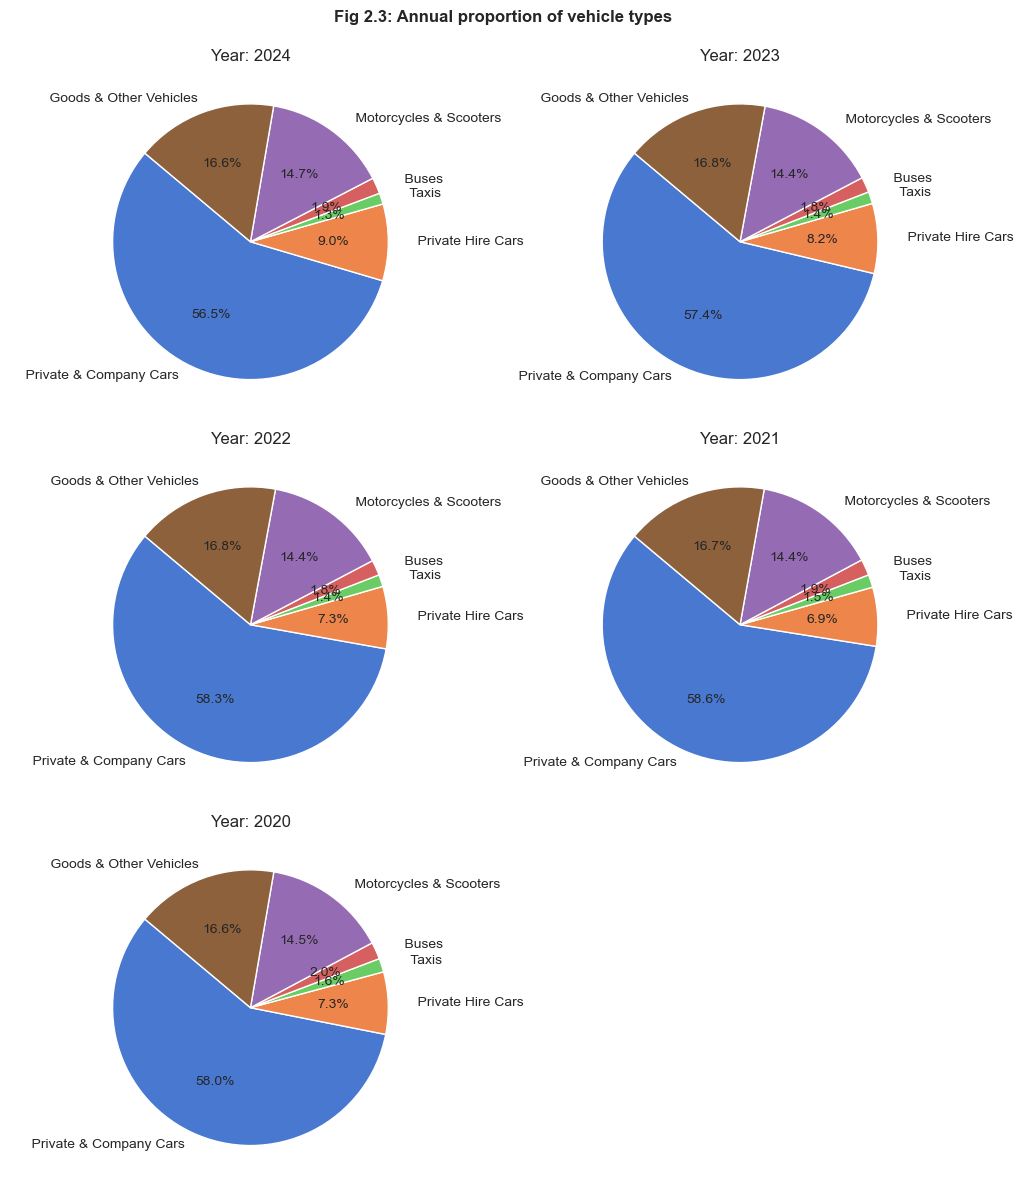

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

print(dataset_fig_2_3)

cols_for_snsplot = (list(dataset_fig_2_3.columns))[1:]

num_col = 2
num_rows = math.ceil(len(cols_for_snsplot) / num_col)

sns.set_theme(style="whitegrid")
colors = sns.color_palette("muted")
fig, axes = plt.subplots(num_rows, num_col, figsize=(10, 12))

for i, column_name in enumerate(cols_for_snsplot):
    ax = axes.flat[i]
    ax.pie(dataset_fig_2_3[column_name], 
           labels=dataset_fig_2_3['DataSeries'], 
           autopct='%1.1f%%', 
           colors=colors,
           startangle=140,
           textprops={'fontsize': 10})
    ax.set_title(f'Year: {column_name}')

for j in range(i + 1, num_rows * num_col):
    axes.flat[j].axis('off')

plt.suptitle('Fig 2.3: Annual proportion of vehicle types', fontsize=12, fontweight='bold', y=0.99) 

plt.tight_layout()
plt.savefig(figure_files["fig_2_3"], dpi=300, bbox_inches='tight')
plt.show()

---------------------------
**Section 3**

**section 3.1) data_set_3_1**

data.gov.sg dataset: Current Banks Interest Rates (End Of Period), Monthly

URL: https://data.gov.sg/datasets/d_5fe5a4bb4a1ecc4d8a56a095832e2b24/view

filename: CurrentBanksInterestRatesEndOfPeriodMonthly.csv

output result analysis plot filename: N.A. (interactive bokeh plot in notebook)

output plot type: Interactive line chart

**section 3.2) data_set_3_2**

data.gov.sg dataset: Taxable Individuals by Assessed Income Group

URL: https://data.gov.sg/datasets?query=income&resultId=d_f394f202534237671d39b17bd3b506ec&dataExplorerPage=67 

filename: TaxableIndividualsbyAssessedIncomeGroup.csv

output result analysis plot filename: N.A. (interactive bokeh plot in notebook)

output plot type: Interactive mix plot

**Section 3.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2020-2024 

[3] Transformation to new dataset
- Generate new array of date values in standard year-month numerical format for data values by converting from original date format
- Generate new array of filtered statistics 
- Combined both arrays for data and date into a dictionary used for plotting

[4] Data presentation 
- Perform various plot adjustments and enable interactive features to plot statistics to answer section objective

In [12]:
import pandas as pd
import datetime

def df_inspection(df_check):
    print("----- Inspecting original dataframe ----- ")
    print("--- column datatypes ---")
    print(df_check.dtypes)
    print("--- column counts ---")
    print(df_check.count())
    print("--- Sampling head rows --- ")
    print(df_check.head(5))
    print("----- End of inspecting ----- ")


debug_on = False

filename = dataset_files["dataset_3_1"]
df_0 = pd.read_csv(filename, sep=',')
df_inspection(df_0)

rp = r'^DataSeries$|^202[0-4]'
df_0 = df_0.filter(regex=rp, axis=1)
print(df_0)

col_names_ls = (list(df_0.columns))[1:]

date_ls = [(datetime.datetime.strptime(x, '%Y%b')).strftime('%Y-%m') for x in col_names_ls]

df_1 = df_0.loc[6, '2024Dec':]
sora_ls = df_1.astype(float).tolist()

if debug_on:
    print(date_ls)
    print(sora_ls)

dataset_fig_3_1 = {'date': date_ls, 'data': sora_ls}

print(dataset_fig_3_1)
df_0 = df_1 = None

----- Inspecting original dataframe ----- 
--- column datatypes ---
DataSeries     object
2025Nov       float64
2025Oct       float64
2025Sep       float64
2025Aug       float64
               ...   
1988May        object
1988Apr        object
1988Mar        object
1988Feb        object
1988Jan        object
Length: 456, dtype: object
--- column counts ---
DataSeries    8
2025Nov       8
2025Oct       8
2025Sep       8
2025Aug       8
             ..
1988May       8
1988Apr       8
1988Mar       8
1988Feb       8
1988Jan       8
Length: 456, dtype: int64
--- Sampling head rows --- 
                                          DataSeries  2025Nov  2025Oct  \
0          Government Securities - 5-Year Bond Yield     1.75     1.63   
1          Government Securities - 2-Year Bond Yield     1.38     1.40   
2         Government Securities - 10-Year Bond Yield     2.12     1.99   
3  Government Securities - 1-Year Treasury Bills ...     1.35     1.35   
4         Government Securities - 15-Year

In [ ]:
import numpy as np

from bokeh.layouts import column
from bokeh.models import ColumnDataSource, RangeTool
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
output_notebook()

dates = np.array(dataset_fig_3_1['date'], dtype=np.datetime64)
source = ColumnDataSource(data=dict(date=dates, data=dataset_fig_3_1['data']))

p = figure(height=400, width=800, tools="xpan,xwheel_zoom,reset",
           x_axis_type="datetime", x_axis_location="above", window_axis="x",
           background_fill_color="#efefef", x_range=(dates[10], dates[15]))

p.line('date', 'data', source=source)
p.yaxis.axis_label = 'Singapore Overnight Rate Average (%)'

select = figure(title="Click drag or modify the selection box edges to change the range above",
                height=170, width=800,
                x_axis_type="datetime", y_axis_type='linear',
                tools="", toolbar_location=None, background_fill_color="#efefef")
select.x_range.range_padding = 0
select.x_range.bounds = "auto"
select.yaxis.axis_label = 'S.O.R.A (%)'

range_tool = RangeTool(x_range=p.x_range, start_gesture="pan")
range_tool.overlay.fill_color = "navy"
range_tool.overlay.fill_alpha = 0.2

select.line('date', 'data', source=source)
select.ygrid.grid_line_color = None
select.add_tools(range_tool)

show(column(p, select))
# note if bokeh plot does not show after running all cells, run this individual cell again and the bokeh plot should appear

Loading BokehJS ...

**Section 3.2**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2020-2024 
- Extract rows in income ranges defined  

[3] Array mathematics
- Perform summation calcuation for whole year for number of taxpayers and assessable income

[4] Transformation to new dataset
- Generate filtered statistics of year and income group and save to each respective list for number of taxpayers nad assessable income
- Generate summed statistics and save to each respective list for number of taxpayers and assessable income

[5] Data presentation 
- Perform various plot adjustments and enable interactive features to plot statistics to answer section objective

In [14]:
import pandas as pd

def df_inspection(df_check):
    print("----- Inspecting original dataframe ----- ")
    print("--- column datatypes ---")
    print(df_check.dtypes)
    print("--- column counts ---")
    print(df_check.count())
    print("--- Sampling head rows --- ")
    print(df_check.head(5))
    print("----- End of inspecting ----- ")

debug_on = False

filename = dataset_files["dataset_3_2"]
df_0 = pd.read_csv(filename, sep=',')
df_inspection(df_0)

df_0 = df_0.astype({'year_of_assessment': 'str'})
df_0 = df_0.drop(columns=['chargeable_income', 'net_tax_assessed'])

years = ('2020', '2021', '2022', '2023', '2024')
income_grp_start = ('100,001', '150,001', '200,001', '300,001', '400,001', '500,001', '1,000,001')
resident_type = 'tax resident'

df_1 = df_0[df_0['year_of_assessment'].str.startswith(years) & df_0['assessed_income_group'].str.startswith(income_grp_start) & (df_0['resident_type'].str.lower() == resident_type)]

if debug_on:
    print(df_1.count())
    print(df_1.head(20))

df_taxpayers_ls = df_1['number_of_taxpayers'].tolist()
df_income_ls = df_1['assessable_income'].tolist()

if debug_on:
    print(df_taxpayers_ls)
    print(df_income_ls)

sum_taxpayers_ls = []
sum_income_ls = []

for y in years:
    df_temp = df_1[df_1['year_of_assessment'] == y]
    sum_taxpayers_ls.append( int(df_temp['number_of_taxpayers'].sum()) )
    sum_income_ls.append( int(df_temp['assessable_income'].sum()) )
    df_temp = None

if debug_on:
    print(sum_taxpayers_ls)
    print(sum_income_ls)

column_data_dict = {'taxpayers': df_taxpayers_ls, 'income': df_income_ls}
sum_data_dict = {'taxpayers': sum_taxpayers_ls, 'income': sum_income_ls}

dataset_fig_3_2 = {'years': list(years), 'data_column': column_data_dict, 'data_sum': sum_data_dict}
df_0 = df_1 = None

print(dataset_fig_3_2)

----- Inspecting original dataframe ----- 
--- column datatypes ---
year_of_assessment        int64
assessed_income_group    object
resident_type            object
number_of_taxpayers       int64
assessable_income         int64
chargeable_income        object
net_tax_assessed          int64
dtype: object
--- column counts ---
year_of_assessment       672
assessed_income_group    672
resident_type            672
number_of_taxpayers      672
assessable_income        672
chargeable_income        672
net_tax_assessed         672
dtype: int64
--- Sampling head rows --- 
   year_of_assessment assessed_income_group resident_type  \
0                2004        20,000 & below  Tax Resident   
1                2004       20,001 - 25,000  Tax Resident   
2                2004       25,001 - 30,000  Tax Resident   
3                2004       30,001 - 40,000  Tax Resident   
4                2004       40,001 - 50,000  Tax Resident   

   number_of_taxpayers  assessable_income chargeable_income  

In [ ]:
from bokeh.models import FactorRange, Div
from bokeh.palettes import RdBu4, BrBG4
from bokeh.plotting import figure, show
from bokeh.layouts import column

def generate_xlabel_tuple(years_dataset, income_grps_def):
    years = years_dataset
    income_grp_ranges = income_grps_def
    category_all_ls = []

    for y in years:
        for grp in income_grp_ranges:
            category_all_ls.append([y, grp])

    category_all_tp = tuple(map(tuple, category_all_ls))  
    return category_all_tp

years_cat_tp = tuple(dataset_fig_3_2['years'])
income_grp_ranges = ['100k-150k', '150k-200k', '200k-300k', '300k-400k', '400k-500k', '500k-1M', 'Above 1M']
income_cat_tp = generate_xlabel_tuple(list(years_cat_tp), income_grp_ranges)

fill_color, line_color = BrBG4[2:]

tooltips = [("Category", "@x"), ("Category Y:", "@top{0,0}"), ("Year total:", "@y{0,0}")]

# ---- first plot ----
p1 = figure(x_range=FactorRange(*income_cat_tp), height=500, width=1200, background_fill_color="#fafafa", 
           toolbar_location=None, tools="hover", tooltips=tooltips,
           title="Number of taxpayers per income group")

data_taxpayers = dataset_fig_3_2['data_column']['taxpayers']
p1.vbar(x=income_cat_tp, top=data_taxpayers, width=0.8, fill_color=fill_color, fill_alpha=0.8, line_color=line_color, line_width=1.2)

data_taxpayers_sum = dataset_fig_3_2['data_sum']['taxpayers']
p1.line(x=years_cat_tp, y=data_taxpayers_sum, color=line_color, line_width=3)
p1.scatter(x=years_cat_tp, y=data_taxpayers_sum, size=10, line_color=line_color, fill_color="white", line_width=3)

p1.y_range.start = 0
p1.x_range.range_padding = 0.1
p1.xaxis.major_label_orientation = 1
p1.xgrid.grid_line_color = None
p1.xaxis.axis_label = "Income groups for year"

p1.yaxis.formatter = NumeralTickFormatter(format="0a")
p1.yaxis.axis_label = "Number of Taxpayers - Per group / year total"

# ---- second plot ----

fill_color, line_color = RdBu4[2:]

p2 = figure(x_range=FactorRange(*income_cat_tp), height=500, width=1200, background_fill_color="#fafafa", 
           toolbar_location=None, tools="hover", tooltips=tooltips, 
           title="Assessable income per income group")

data_income = dataset_fig_3_2['data_column']['income']
p2.vbar(x=income_cat_tp, top=data_income, width=0.8, fill_color=fill_color, fill_alpha=0.8, line_color=line_color, line_width=1.2)

data_income_sum = dataset_fig_3_2['data_sum']['income']
p2.line(x=years_cat_tp, y=data_income_sum, color=line_color, line_width=3)
p2.scatter(x=years_cat_tp, y=data_income_sum, size=10, line_color=line_color, fill_color="white", line_width=3)

p2.y_range.start = 0
p2.x_range.range_padding = 0.1
p2.xaxis.major_label_orientation = 1
p2.xgrid.grid_line_color = None
p2.xaxis.axis_label = "Income groups for year"

p2.yaxis.formatter = NumeralTickFormatter(format="0a")
p2.yaxis.axis_label = "Assessable income - Per group / year total"

# ----------------

overall_title = Div(
    text = "Fig 3.2: Mix plot for number of taxpayers and assessable income per income group for study period", 
    styles = {
        "font-size": "12pt",
        "font-weight": "bold",
        "text-align": "center",
        "width": "100%"
    },
    width = 600
    )
layout = column(overall_title, p1, p2)
show(layout)
# note if bokeh plot does not show after running all cells, run this individual cell again and the bokeh plot should appear
#print(income_cat_tp)


---------------------------
**Section 4**

**section 4.1) data_set_4_1**

data.gov.sg dataset: Public Transport Operation And Ridership, Annual

URL: https://data.gov.sg/datasets/d_ba615ec4cc5d9f5b7800ad82057f36f1/view 

filename: PublicTransportOperationAndRidershipAnnual.csv

output result analysis plot filename: fig_4_1.jpg

output plot type: Scatter plot

**Section 4.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2020-2024 
- Extract rows in transportation categories defined  

[3] Array mathematics
- Perform pearson coefficient calculation for each category using COE cat A median price vs average daily ridership for study period

[4] Transformation to new dataset
- Generate filtered statistics of average daily ridership for each category and each year combined with COE cat A median price for each year 
- Generate coefficient statistics for each category and save to a list 

[5] Data presentation 
- Perform various plot adjustments and annotations to plot statistics to answer section objective

In [16]:
import pandas as pd
import copy

def df_inspection(df_check):
    print("----- Inspecting original dataframe ----- ")
    print("--- column datatypes ---")
    print(df_check.dtypes)
    print("--- column counts ---")
    print(df_check.count())
    print("--- Sampling head rows --- ")
    print(df_check.head(5))
    print("----- End of inspecting ----- ")

def calculate_pearson_coeff(df_source, type_name_ls):
    pc_dict = dict.fromkeys(type_name_ls, 0.0)
    for key in pc_dict.keys():
        df_filter = df_source[df_source['dataset'].str.contains(key)]
        df_filter = df_filter.drop(columns=['dataset', 'year']).sort_index(ascending=False)
        df_pc = df_filter.corr(method='pearson')
        pc_dict[key] = round(float(df_pc.iloc[1,0]), 3)
        if debug_on:
            print(df_pc)
            print(df_filter)
        print(f"{key} : {pc_dict[key]}")
    return pc_dict

debug_on = False

filename = dataset_files["dataset_4_1"]
df_0 = pd.read_csv(filename, sep=',')
df_inspection(df_0)

years = ('Average Daily Ridership ', 'Average Daily Trip')
# perform boolean masking to filter data for study period and interested rows
df_1 = df_0[df_0['DataSeries'].str.startswith(years)]
df_1 = df_1.loc[:, 'DataSeries':'2020']

merge_data_ls = []
merge_type_ls = []
merge_year_ls = []
merge_coe_catA_ls = []

type_name_ls = ["Average Daily Ridership MRT", "Average Daily Ridership LRT", "Average Daily Ridership Bus", "Average Daily Ridership P2P"]
type_name_cal_pc = copy.deepcopy(type_name_ls)
year_name_ls = list(df_1.columns)[1:]
coe_catA_ls = dataset_fig_1b['data']

for index_id in list(df_1.index):
    row_data_ls = df_1.loc[index_id, '2024':'2020'].astype('int').to_list()
    type_name = type_name_ls.pop(0)
    row_type_name_ls = [type_name] * len(row_data_ls)

    merge_type_ls.extend(row_type_name_ls)
    merge_data_ls.extend(row_data_ls)
    merge_year_ls.extend(year_name_ls)
    merge_coe_catA_ls.extend(coe_catA_ls)

# generating a new dataframe combining CAT A premium prices, average daily ridership, year and category for plotting
d1 = {"dataset": merge_type_ls, "COE cat A premium year median": merge_coe_catA_ls, "ridership": merge_data_ls, "year": merge_year_ls}
index_ls = [int(x) for x in range(len(merge_data_ls))]

df_2 = pd.DataFrame(d1, index=index_ls)
dataset_fig_4_1 = df_2

if debug_on:
    print(df_1)
    print(merge_type_ls)
    print(merge_data_ls)
    print(merge_year_ls)
    print(merge_coe_catA_ls)
    print(f"Checking all lengths: {len(merge_type_ls)}, {len(merge_data_ls)}, {len(merge_year_ls)}, {len(merge_coe_catA_ls)}")
# calculated pearson coefficient is saved to another dataset as dictionary
dataset_fig_4_1b = calculate_pearson_coeff(df_2, type_name_cal_pc)

print(dataset_fig_4_1)
print(dataset_fig_4_1b)

df_0 = df_1 = df_2 = None

----- Inspecting original dataframe ----- 
--- column datatypes ---
DataSeries     object
2024           object
2023          float64
2022          float64
2021          float64
2020          float64
2019          float64
2018           object
2017           object
2016           object
2015           object
2014           object
2013           object
2012           object
2011           object
2010           object
2009           object
2008           object
2007           object
2006           object
2005           object
2004           object
2003           object
2002           object
2001           object
2000           object
1999           object
1998           object
1997           object
1996           object
1995           object
1994           object
1993           object
1992           object
1991           object
1990           object
dtype: object
--- column counts ---
DataSeries    11
2024          11
2023          11
2022          11
2021          11
2020          11
20

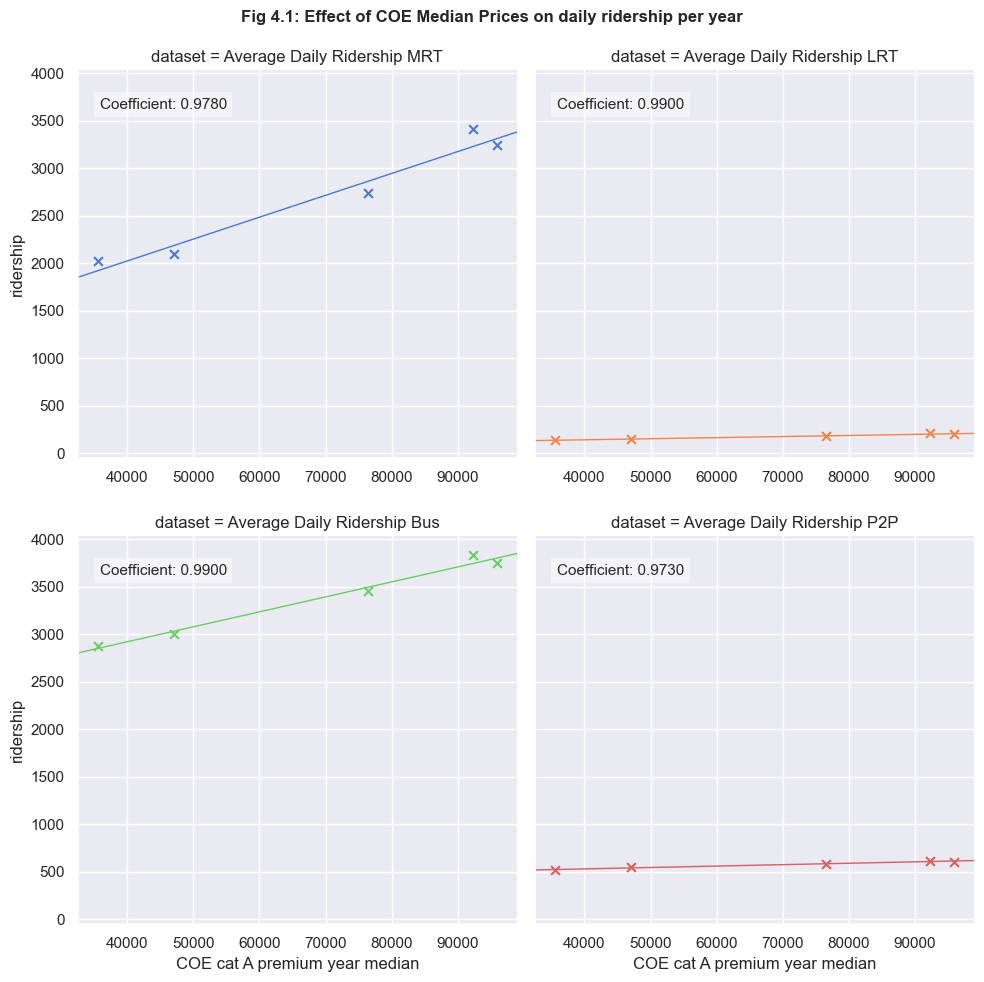

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

pearson_coefficients = dataset_fig_4_1b

p = sns.lmplot(
    data=dataset_fig_4_1, x="COE cat A premium year median", y="ridership", col="dataset", hue="dataset",
    col_wrap=2, palette="muted", ci=None,
    height=5, 
    truncate=False,
    markers="x",
    scatter_kws={"s": 40, "alpha": 1},
    line_kws={"lw": 1}
)

for ax in p.axes.flat:
    ax.tick_params(axis="x", labelbottom=True)
    full_title = ax.get_title()
    dataset_name = full_title.split('= ')[-1]
    coef_val = pearson_coefficients.get(dataset_name, 0)
    ax.text(
        0.05, 0.9, 
        f"Coefficient: {coef_val:.4f}", 
        transform=ax.transAxes, 
        fontsize=11, 
        fontweight='normal',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
    )    

p.figure.subplots_adjust(hspace=0.2, top=0.92)
p.figure.suptitle("Fig 4.1: Effect of COE Median Prices on daily ridership per year", fontsize=12, fontweight='bold')
plt.savefig(figure_files["fig_4_1"], dpi=300, bbox_inches='tight')

-----------------------

**Database section (optional)**

This section is optional to execute as the main sections 1-4 for EDA of data analysis topic has been completed by this point.

Implemented steps

[1] Establish connection and initialize database                   
- Check if mySQL connection can be established using credentials and provided localhost IP
- If database is not present, create new database according to pre-defined name
- Check if dataset tables already exist. If exist, delete all rows in existing tables. If tables don't exist, create new tables according to defined structure.

[2] Inserting data to all tables
- Referencing all processed datasets already created in main sections 1-4 of notebook. 
- Read each processed dataset row by row and insert to respective database table. Entry timestamp is also inserted to table. 

[3] Query data from all tables and convert to pandas dataframe 
- Select all rows for each database table according to selection criteria and query back into python variables for each dataset
- During the query back procedure, raw database table data is manipulated to convert back into correct pandas dataframe format for plotting

[4] Visual presentation of database data
- Importing accompanying python user module, input database-extracted datasets to plotting functions to generate the respective plots to validate the database data.


In [18]:
# SQL

# doYouWantToRunAllSQL = True 
# user, pw, host, db = 'root', 'nsfswbdd123', '127.0.0.1', 'it8701ca2'

if doYouWantToRunAllSQL:
    print("You choose to run the SQL cells sections, You will bear all responsibility to fix SQL API errors if arise")
    print("The mySQL API will use these defined credentials, IP and database name")
    print(f"User name: {user}, Password: {pw}, Host IP: {host}, Database name: {db}")
else:
    print("SQL cells sections are skipped")

You choose to run the SQL cells sections, You will bear all responsibility to fix SQL API errors if arise
The mySQL API will use these defined credentials, IP and database name
User name: root, Password: nsfswbdd123, Host IP: 127.0.0.1, Database name: it8701ca2


In [19]:
import mysql.connector, sys
from mysql.connector import errorcode

table_name_1 = 'dataset_fig_1a'
q_create_table_1 = (f"CREATE TABLE `{table_name_1}` ("
    "`row_id` INT NOT NULL AUTO_INCREMENT,"
    "`row_entry_ts` datetime NOT NULL,"
    "`df_index` INT NOT NULL,"
    "`year` varchar(50) NOT NULL,"
    "`bidding_no` INT NOT NULL,"
    "`vehicle_class` varchar(50) NOT NULL,"
    "`quota` INT NOT NULL,"
    "`bids_success` varchar(50) NOT NULL,"
    "`bids_received` varchar(50) NOT NULL,"
    "`premium` INT NOT NULL,"
    "PRIMARY KEY (`row_id`)"
    ") ENGINE=InnoDB")

table_name_2 = 'dataset_fig_1c'
q_create_table_2 = (f"CREATE TABLE `{table_name_2}` ("
    "`row_id` INT NOT NULL AUTO_INCREMENT,"
    "`row_entry_ts` datetime NOT NULL,"
    "`df_index` varchar(50) NOT NULL,"
    "`Category_A` INT NOT NULL,"
    "`Category_B` INT NOT NULL,"
    "`Category_E` INT NOT NULL,"
    "PRIMARY KEY (`row_id`)"
    ") ENGINE=InnoDB")

table_name_3 = 'dataset_fig_2_1'
q_create_table_3 = (f"CREATE TABLE `{table_name_3}` ("
    "`row_id` INT NOT NULL AUTO_INCREMENT,"
    "`row_entry_ts` datetime NOT NULL,"
    "`df_index` varchar(50) NOT NULL,"
    "`Diesel` INT NOT NULL,"
    "`Diesel_Electric` INT NOT NULL,"
    "`Electric` INT NOT NULL,"
    "`Petrol` INT NOT NULL,"
    "`Petrol_CNG` INT NOT NULL,"
    "`Petrol_Electric` INT NOT NULL,"
    "PRIMARY KEY (`row_id`)"
    ") ENGINE=InnoDB")

table_name_4 = 'dataset_fig_2_2'
q_create_table_4 = (f"CREATE TABLE `{table_name_4}` ("
    "`row_id` INT NOT NULL AUTO_INCREMENT,"
    "`row_entry_ts` datetime NOT NULL,"
    "`df_index` varchar(50) NOT NULL,"
    "`Diesel` INT NOT NULL,"
    "`Electric` INT NOT NULL,"
    "`Others` INT NOT NULL,"
    "`Petrol` INT NOT NULL,"
    "`Petrol_Electric` INT NOT NULL,"
    "PRIMARY KEY (`row_id`)"
    ") ENGINE=InnoDB")

table_name_5 = 'dataset_fig_2_3'
q_create_table_5 = (f"CREATE TABLE `{table_name_5}` ("
    "`row_id` INT NOT NULL AUTO_INCREMENT,"
    "`row_entry_ts` datetime NOT NULL,"
    "`df_index` INT NOT NULL,"
    "`DataSeries` varchar(100) NOT NULL,"
    "`2024` DOUBLE NOT NULL,"
    "`2023` DOUBLE NOT NULL,"
    "`2022` DOUBLE NOT NULL,"
    "`2021` DOUBLE NOT NULL,"
    "`2020` DOUBLE NOT NULL,"
    "PRIMARY KEY (`row_id`)"
    ") ENGINE=InnoDB")

table_name_6 = 'dataset_fig_4_1'
q_create_table_6 = (f"CREATE TABLE `{table_name_6}` ("
    "`row_id` INT NOT NULL AUTO_INCREMENT,"
    "`row_entry_ts` datetime NOT NULL,"
    "`df_index` INT NOT NULL,"
    "`dataset` varchar(100) NOT NULL,"
    "`coe_cat_A_premium` INT NOT NULL,"
    "`ridership` INT NOT NULL,"
    "`year` varchar(50) NOT NULL,"
    "PRIMARY KEY (`row_id`)"
    ") ENGINE=InnoDB")

db_table_ls = [table_name_1, table_name_2, table_name_3, table_name_4, table_name_5, table_name_6]
q_create_table_ls = [q_create_table_1, q_create_table_2, q_create_table_3, q_create_table_4, q_create_table_5, q_create_table_6]

def connect_db():
    is_success = False
    try:
        cnx = mysql.connector.connect(user=user, password=pw, host=host)
        cursor = cnx.cursor()

        db_name = db
        cursor.execute(f"SELECT SCHEMA_NAME FROM information_schema.SCHEMATA WHERE SCHEMA_NAME = '{db_name}'")
        db_exists = cursor.fetchone()
        if db_exists:
            print(f"Connection success, database {db_name} exist.")
        else:
            print(f"Connection success, database {db_name} does not exist.")
            q_create_db = f'CREATE DATABASE {db_name}'
            cursor.execute(q_create_db)
            cnx.commit()
            print(f"Database {db_name} created!")
        is_success = True
    except mysql.connector.Error as err:
        print(f"General MySQL Error: {err}")
        is_success = False
    finally:
        cursor.close()
        cnx.close()
        return is_success

def init_db():
    try:
        cnx = mysql.connector.connect(user=user, password=pw, host=host, database=db)
        print("Database connection is successful")

        cursor = cnx.cursor()

        for i in range(len(db_table_ls)):
            table_name = db_table_ls[i]
            q_create_table = q_create_table_ls[i]
            q_check_table = (f"SHOW TABLES LIKE '{table_name}'")

            cursor.execute(q_check_table)
            result = cursor.fetchone()

            if result:
                print(f"Table '{table_name}' exists.")
                q_clear_table = (f"TRUNCATE TABLE {table_name}")
                cursor.execute(q_clear_table)
                print(f"All rows cleared from existing table {i}: {table_name}")
            else:
                print(f"Table '{table_name}' does not exist.")
                # create new table with defined schema if table does not exist
                cursor.execute(q_create_table)
                cnx.commit()
                print(f"Table {i} - {table_name} created")

    except mysql.connector.Error as err:
        if err.errno == errorcode.ER_BAD_DB_ERROR:
            print("Error: The database does not exist.")
        elif err.errno == errorcode.ER_ACCESS_DENIED_ERROR:
            print("Error: Access denied (check user/password).")
        elif err.errno == 2003: 
            # errorcode.CR_CONN_HOST_ERROR
            print("Error: Cannot connect to MySQL server. Check if the server is running or the host is correct.")
        elif err.errno == 2006: 
            # errorcode.CR_SERVER_GONE_ERROR
            print("Error: The MySQL server connection was lost or timed out.")
        else:
            print(f"General MySQL Error: {err}")
            global doYouWantToRunAllSQL
            doYouWantToRunAllSQL = False
    finally:
        cursor.close()
        cnx.close()


if doYouWantToRunAllSQL:
    print("The mySQL API will use these defined credentials, IP and database name")
    print(f"User name: {user}, Password: {pw}, Host IP: {host}, Database name: {db}")

    connect_db_success = connect_db()
    if connect_db_success:
        init_db()
    else:
        doYouWantToRunAllSQL = False
        print("Database connection failed. Skipping all subsequent database operations.")
else:
    print("SQL cells sections are skipped")

The mySQL API will use these defined credentials, IP and database name
User name: root, Password: nsfswbdd123, Host IP: 127.0.0.1, Database name: it8701ca2
Connection success, database it8701ca2 exist.
Database connection is successful
Table 'dataset_fig_1a' does not exist.
Table 0 - dataset_fig_1a created
Table 'dataset_fig_1c' does not exist.
Table 1 - dataset_fig_1c created
Table 'dataset_fig_2_1' does not exist.
Table 2 - dataset_fig_2_1 created
Table 'dataset_fig_2_2' does not exist.
Table 3 - dataset_fig_2_2 created
Table 'dataset_fig_2_3' does not exist.
Table 4 - dataset_fig_2_3 created
Table 'dataset_fig_4_1' does not exist.
Table 5 - dataset_fig_4_1 created


In [20]:
import pandas as pd
import mysql.connector, sys
from datetime import date, datetime
from mysql.connector import errorcode

now = datetime.now()
row_entry_common_ts = now.strftime('%Y-%m-%d %H:%M:%S')

q_insert_tb1 = ("INSERT INTO dataset_fig_1a (`row_entry_ts`, `df_index`, `year`, `bidding_no`, `vehicle_class`, `quota`, `bids_success`, `bids_received`, `premium`)" 
               "VALUES (%(row_entry_ts)s, %(df_index)s, %(year)s, %(bidding_no)s, %(vehicle_class)s, %(quota)s, %(bids_success)s, %(bids_received)s, %(premium)s)")

q_insert_tb2 = ("INSERT INTO dataset_fig_1c (`row_entry_ts`, `df_index`, `Category_A`, `Category_B`, `Category_E`)" 
               "VALUES (%(row_entry_ts)s, %(df_index)s, %(Category_A)s, %(Category_B)s, %(Category_E)s)")

q_insert_tb3 = ("INSERT INTO dataset_fig_2_1 (`row_entry_ts`, `df_index`, `Diesel`, `Diesel_Electric`, `Electric`, `Petrol`, `Petrol_CNG`, `Petrol_Electric`)" 
               "VALUES (%(row_entry_ts)s, %(df_index)s, %(Diesel)s, %(Diesel-Electric)s, %(Electric)s, %(Petrol)s, %(Petrol-CNG)s, %(Petrol-Electric)s)")

q_insert_tb4 = ("INSERT INTO dataset_fig_2_2 (`row_entry_ts`, `df_index`, `Diesel`, `Electric`, `Others`, `Petrol`, `Petrol_Electric`)" 
               "VALUES (%(row_entry_ts)s, %(df_index)s, %(Diesel)s, %(Electric)s, %(Others)s, %(Petrol)s, %(Petrol-Electric)s)")

q_insert_tb5 = ("INSERT INTO dataset_fig_2_3 (`row_entry_ts`, `df_index`, `DataSeries`, `2024`, `2023`, `2022`, `2021`, `2020`)" 
               "VALUES (%(row_entry_ts)s, %(df_index)s, %(DataSeries)s, %(2024)s, %(2023)s, %(2022)s, %(2021)s, %(2020)s)")

q_insert_tb6 = ("INSERT INTO dataset_fig_4_1 (`row_entry_ts`, `df_index`, `dataset`, `coe_cat_A_premium`, `ridership`, `year`)" 
               "VALUES (%(row_entry_ts)s, %(df_index)s, %(dataset)s, %(COE cat A premium year median)s, %(ridership)s, %(year)s)")

def print_ds_debug():
    print("------")
    # print(dataset_fig_1a)
    # print("---")
    # print(dataset_fig_1a.dtypes)
    # print("---")
    # print(dataset_fig_1a.index)
    # print("---")
    print("------")

def insert_ds_to_table(df_source, q_insert_tb):
    df_source_cols = list(df_source.columns)
    index_dtype = df_source.index.inferred_type
    # print(df_source_cols)
    # print(len(df_source_cols))
    try:
        cnx = mysql.connector.connect(user=user, password=pw, host=host, database=db)
        print("Database connection is successful")
        cursor = cnx.cursor()

        for index, col in df_source.iterrows():
            d_row_data = {}
            row_value_ls = list(col)
            # insert row values to dictionary
            for i in range(len(df_source_cols)):
                col_name = df_source_cols[i]
                d_row_data[col_name] = row_value_ls[i]
            # insert index to dictionary
            d_row_data['df_index'] = index
            # insert timestamp to dictionary
            d_row_data['row_entry_ts'] = row_entry_common_ts
            print(d_row_data)
            cursor.execute(q_insert_tb, d_row_data)
            cnx.commit()

        print("Notebook dataset has been successfully inserted to database")
    except mysql.connector.Error as err:
        print(f"General MySQL Error: {err}")
        global doYouWantToRunAllSQL
        doYouWantToRunAllSQL = False
    finally:
        cursor.close()
        cnx.close()

if doYouWantToRunAllSQL:
    print("The mySQL API will use these defined credentials, IP and database name")
    print(f"User name: {user}, Password: {pw}, Host IP: {host}, Database name: {db}")
    insert_ds_to_table(dataset_fig_1a, q_insert_tb1)
    insert_ds_to_table(dataset_fig_1c, q_insert_tb2)
    insert_ds_to_table(dataset_fig_2_1, q_insert_tb3)
    insert_ds_to_table(dataset_fig_2_2, q_insert_tb4)
    insert_ds_to_table(dataset_fig_2_3, q_insert_tb5)
    insert_ds_to_table(dataset_fig_4_1, q_insert_tb6)
else:
    print("SQL cells sections are skipped")

The mySQL API will use these defined credentials, IP and database name
User name: root, Password: nsfswbdd123, Host IP: 127.0.0.1, Database name: it8701ca2
Database connection is successful
{'year': '2020', 'bidding_no': 1, 'vehicle_class': 'Category A', 'quota': 1035, 'bids_success': '1026', 'bids_received': '1450', 'premium': 35320, 'df_index': 1200, 'row_entry_ts': '2026-02-01 21:36:57'}
{'year': '2020', 'bidding_no': 1, 'vehicle_class': 'Category B', 'quota': 1022, 'bids_success': '1021', 'bids_received': '1229', 'premium': 37109, 'df_index': 1201, 'row_entry_ts': '2026-02-01 21:36:57'}
{'year': '2020', 'bidding_no': 1, 'vehicle_class': 'Category E', 'quota': 384, 'bids_success': '377', 'bids_received': '541', 'premium': 38000, 'df_index': 1204, 'row_entry_ts': '2026-02-01 21:36:57'}
{'year': '2020', 'bidding_no': 2, 'vehicle_class': 'Category A', 'quota': 1034, 'bids_success': '1025', 'bids_received': '1390', 'premium': 35010, 'df_index': 1205, 'row_entry_ts': '2026-02-01 21:36:57

In [21]:
import pandas as pd
import mysql.connector, sys
from datetime import date, datetime
from mysql.connector import errorcode

min_ts_select = datetime(2026, 1, 1, 0, 0, 0)
q_values_d = {'min_ts': min_ts_select}

dataset_fig_1a_dbq = dataset_fig_1c_dbq = dataset_fig_2_1_dbq = dataset_fig_2_2_dbq = dataset_fig_2_3_dbq = dataset_fig_4_1_dbq = None
dataset_fig_dbq_ts = {}

sql_table_name_define = ("dataset_fig_1a", "dataset_fig_1c", "dataset_fig_2_1", "dataset_fig_2_2", "dataset_fig_2_3", "dataset_fig_4_1")

dataset_fig_col_names = {
    sql_table_name_define[0]: ['row_id', 'row_entry_ts', 'df_index', 'year', 'bidding_no', 'vehicle_class', 'quota', 'bids_success', 'bids_received', 'premium'],
    sql_table_name_define[1]: ['row_id', 'row_entry_ts', 'df_index', 'Category_A', 'Category_B', 'Category_E'],
    sql_table_name_define[2]: ['row_id', 'row_entry_ts', 'df_index', 'Diesel', 'Diesel-Electric', 'Electric', 'Petrol', 'Petrol-CNG', 'Petrol-Electric'],
    sql_table_name_define[3]: ['row_id', 'row_entry_ts', 'df_index', 'Diesel', 'Electric', 'Others', 'Petrol', 'Petrol-Electric'],
    sql_table_name_define[4]: ['row_id', 'row_entry_ts', 'df_index', 'DataSeries', '2024', '2023', '2022', '2021', '2020'],
    sql_table_name_define[5]: ['row_id', 'row_entry_ts', 'df_index', 'dataset', 'COE cat A premium year median', 'ridership', 'year']
}

dataset_fig_index_type = {
    sql_table_name_define[0]: "int",
    sql_table_name_define[1]: "str",
    sql_table_name_define[2]: "str",
    sql_table_name_define[3]: "str",
    sql_table_name_define[4]: "int",
    sql_table_name_define[5]: "int",
}

def select_all_db(table_name, df_index_type, df_col_define):
    try:
        cnx = mysql.connector.connect(user=user, password=pw, host=host, database=db)
        print("Database connection is successful")
        cursor = cnx.cursor()

        q_select = (f"SELECT * FROM {table_name} WHERE `row_entry_ts` > %(min_ts)s")
        cursor.execute(q_select, q_values_d)
        df_db = pd.DataFrame(cursor.fetchall(), columns = df_col_define)
        
        df_index_ls = []
        if df_index_type == "int":
            df_index_ls = df_db['df_index'].astype(int).to_list()
        else:
            df_index_ls = df_db['df_index'].astype(str).to_list()

        df_db.index = df_index_ls
        df_ts = (df_db['row_entry_ts'].astype(str).to_list())[0]
        dataset_fig_dbq_ts.update({str(table_name): df_ts})
        df_db.drop(columns=['row_id', 'row_entry_ts', 'df_index'], inplace=True)
        
        # print(df_db)
        # print(df_index_ls)
        # print(type(df_index_ls[0]))
        print(f"Retrieved table {table_name} data from database")
        return df_db
    except mysql.connector.Error as err:
        print(f"General MySQL Error: {err}")
        global doYouWantToRunAllSQL
        doYouWantToRunAllSQL = False
    finally:
        cursor.close()
        cnx.close()

if doYouWantToRunAllSQL:
    print("The mySQL API will use these defined credentials, IP and database name")
    print(f"User name: {user}, Password: {pw}, Host IP: {host}, Database name: {db}")

    db_name = sql_table_name_define[0]
    dataset_fig_1a_dbq = select_all_db(db_name, dataset_fig_index_type[db_name], dataset_fig_col_names[db_name])

    db_name = sql_table_name_define[1]
    dataset_fig_1c_dbq = select_all_db(db_name, dataset_fig_index_type[db_name], dataset_fig_col_names[db_name])

    db_name = sql_table_name_define[2]
    dataset_fig_2_1_dbq = select_all_db(db_name, dataset_fig_index_type[db_name], dataset_fig_col_names[db_name])

    db_name = sql_table_name_define[3]
    dataset_fig_2_2_dbq = select_all_db(db_name, dataset_fig_index_type[db_name], dataset_fig_col_names[db_name])

    db_name = sql_table_name_define[4]
    dataset_fig_2_3_dbq = select_all_db(db_name, dataset_fig_index_type[db_name], dataset_fig_col_names[db_name])

    db_name = sql_table_name_define[5]
    dataset_fig_4_1_dbq = select_all_db(db_name, dataset_fig_index_type[db_name], dataset_fig_col_names[db_name])

    print("----- checking all datasets read back from databases -----")
    print(f"-- Dataset retrieved: {sql_table_name_define[0]} --")
    print(dataset_fig_1a_dbq)
    print(f"\n-- Dataset retrieved: {sql_table_name_define[1]} --")
    print(dataset_fig_1c_dbq)
    print(f"\n-- Dataset retrieved: {sql_table_name_define[2]} --")
    print(dataset_fig_2_1_dbq)
    print(f"\n-- Dataset retrieved: {sql_table_name_define[3]} --")
    print(dataset_fig_2_2_dbq)
    print(f"\n-- Dataset retrieved: {sql_table_name_define[4]} --")
    print(dataset_fig_2_3_dbq)
    print(f"\n-- Dataset retrieved: {sql_table_name_define[5]} --")
    print(dataset_fig_4_1_dbq)
    print(f"\n-- Dataset timestamps --")
    print(dataset_fig_dbq_ts)
else:
    print("SQL cells sections are skipped")

The mySQL API will use these defined credentials, IP and database name
User name: root, Password: nsfswbdd123, Host IP: 127.0.0.1, Database name: it8701ca2
Database connection is successful
Retrieved table dataset_fig_1a data from database
Database connection is successful
Retrieved table dataset_fig_1c data from database
Database connection is successful
Retrieved table dataset_fig_2_1 data from database
Database connection is successful
Retrieved table dataset_fig_2_2 data from database
Database connection is successful
Retrieved table dataset_fig_2_3 data from database
Database connection is successful
Retrieved table dataset_fig_4_1 data from database
----- checking all datasets read back from databases -----
-- Dataset retrieved: dataset_fig_1a --
      year  bidding_no vehicle_class  quota bids_success bids_received  \
1200  2020           1    Category A   1035         1026          1450   
1201  2020           1    Category B   1022         1021          1229   
1204  2020     

Loading BokehJS ...

Loading BokehJS ...

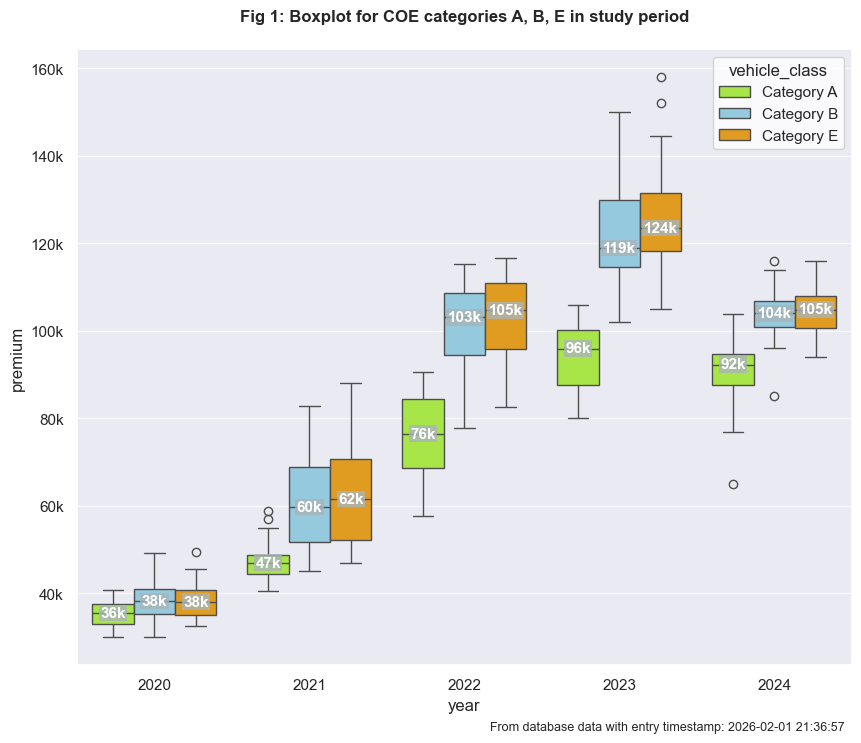

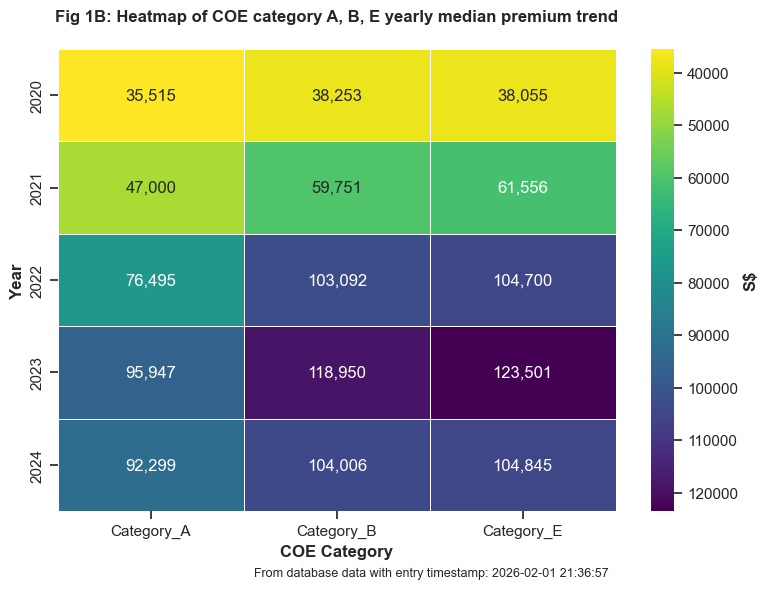

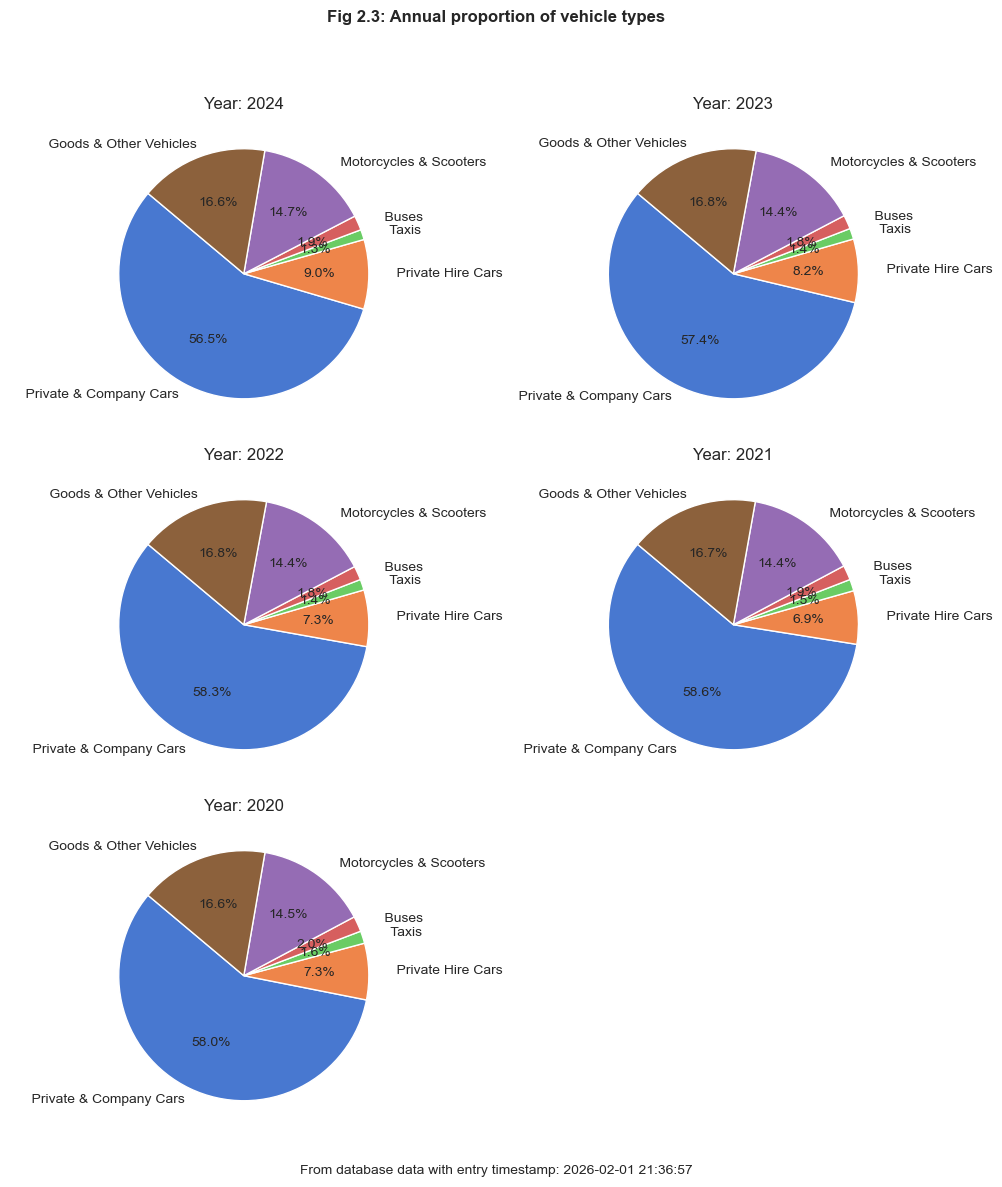

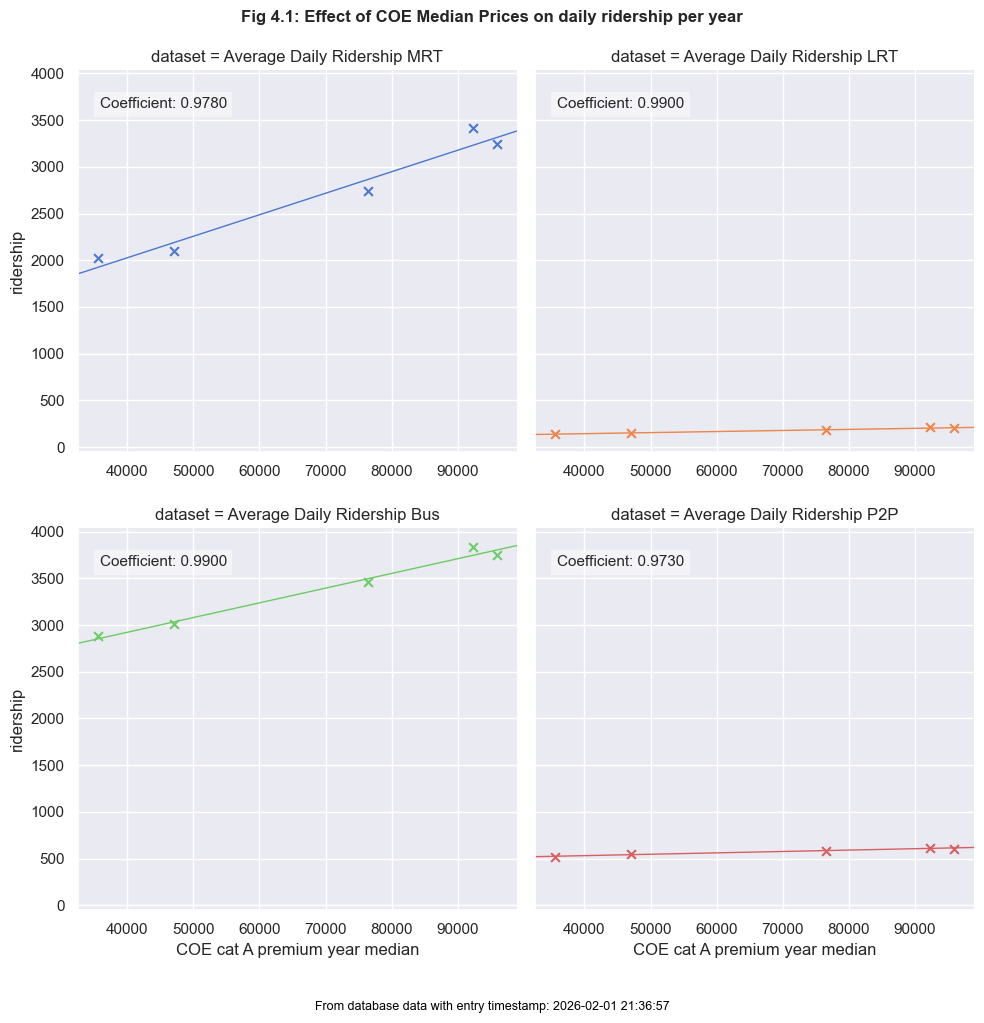

In [ ]:
import ca2module
import importlib
importlib.reload(ca2module)

if doYouWantToRunAllSQL:
    if dataset_fig_1a_dbq is not None:
        ca2module.plot_dataset_fig_1(dataset_fig_1a_dbq, dataset_fig_dbq_ts['dataset_fig_1a'])
    if dataset_fig_1c_dbq is not None:
        ca2module.plot_dataset_fig_1c(dataset_fig_1c_dbq, dataset_fig_dbq_ts['dataset_fig_1c'])
    if dataset_fig_2_1_dbq is not None:
        ca2module.plot_dataset_fig_2_1(dataset_fig_2_1_dbq, dataset_fig_dbq_ts['dataset_fig_2_1'])
    if dataset_fig_2_2_dbq is not None:
        ca2module.plot_dataset_fig_2_2(dataset_fig_2_2_dbq, dataset_fig_dbq_ts['dataset_fig_2_2'])
    if dataset_fig_2_3_dbq is not None:
        ca2module.plot_dataset_fig_2_3(dataset_fig_2_3_dbq, dataset_fig_dbq_ts['dataset_fig_2_3'])
    if dataset_fig_4_1_dbq is not None:    
        ca2module.plot_dataset_fig_4_1(dataset_fig_4_1_dbq, dataset_fig_4_1b, dataset_fig_dbq_ts['dataset_fig_4_1'])
else:
    print("SQL cells sections are skipped")

# note if bokeh plot does not show after running all cells, run this individual cell again and the bokeh plot should appear

**End of notebook**

---------------------------------------